In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Bilimsel Sabitlik (Reproducibility)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Grafiklerin siyah-beyaz akademik formatı
plt.style.use('grayscale')

print("✅ Kütüphaneler yüklendi ve Seed ayarlandı!")

✅ Kütüphaneler yüklendi ve Seed ayarlandı!


In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "KaderTerik"
os.environ["KAGGLE_KEY"] = "eaa63ac073bb6e0e65b4790c514e5e18"

print("✅ Kaggle API bilgileri ayarlandı.")

✅ Kaggle API bilgileri ayarlandı.


In [ ]:
!pip -q install kaggle

print("Kaggle API test ediliyor...\n")
!kaggle datasets list -s faceforensics

Kaggle API test ediliyor...

ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
greatgamedota/faceforensics                                      FaceForensics                                         724841395  2020-02-19 17:42:41.720000           4822         38  0.75             
xdxd003/ff-c23                                                   FaceForensics++ Dataset (C23)                       17891522096  2024-12-07 06:16:49.157000          41421        105  1                
hungle3401/faceforensics                                         FaceForensics++                                      2927395799  2024-02-13 04:35:27.907000       

In [4]:
import os

os.environ["KAGGLE_USERNAME"] = "KaderTerik"
os.environ["KAGGLE_KEY"] = "eaa63ac073bb6e0e65b4790c514e5e18"

!pip install -q kaggle

DATASET = "gradientvoyager/faceforensics-c23-extracted-faces-100k"

print("📥 Dataset indiriliyor...")
!kaggle datasets download -d $DATASET

import zipfile

zip_name = DATASET.split("/")[-1] + ".zip"

print("📦 Zip açılıyor...")
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("dataset")

print("✅ Dataset hazır!")

📥 Dataset indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k
License(s): CC-BY-NC-SA-4.0
100% 2.46G/2.46G [00:22<00:00, 120MB/s]

📦 Zip açılıyor...
✅ Dataset hazır!


In [5]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)
    if len(files) > 0:
        print("Örnek dosya:", files[:3])
    print("-"*60)

dataset
------------------------------------------------------------
dataset/dataset_processed_split
Örnek dosya: ['dataset_manifest.csv']
------------------------------------------------------------
dataset/dataset_processed_split/test
------------------------------------------------------------
dataset/dataset_processed_split/test/FaceSwap
Örnek dosya: ['399_488_f71.jpg', '552_851_f124.jpg', '495_512_f39.jpg']
------------------------------------------------------------
dataset/dataset_processed_split/test/DeepFakeDetection
Örnek dosya: ['05_16__kitchen_still__053HPS1G_f331.jpg', '05_28__kitchen_still__W3J028UG_f0.jpg', '22_23__outside_talking_pan_laughing__J671JKCH_f39.jpg']
------------------------------------------------------------
dataset/dataset_processed_split/test/Face2Face
Örnek dosya: ['809_799_f42.jpg', '399_488_f71.jpg', '701_579_f81.jpg']
------------------------------------------------------------
dataset/dataset_processed_split/test/FaceShifter
Örnek dosya: ['574_547_f

🔍 1. KLASÖR VE BOZUK DOSYA KONTROLÜ (Hızlı Tarama)
Eğitim (Train) Seti Toplam: 128477 kare
Test Seti Toplam: 26276 kare

🚨 2. DATA LEAKAGE (VERİ SIZINTISI) KONTROLÜ
✅ HARİKA! Train ve Test setlerindeki video kaynakları tamamen farklı. Veri Sızıntısı YOK.

🖼️ 3. CROP KALİTESİ KONTROLÜ (16 Rastgele Kare)


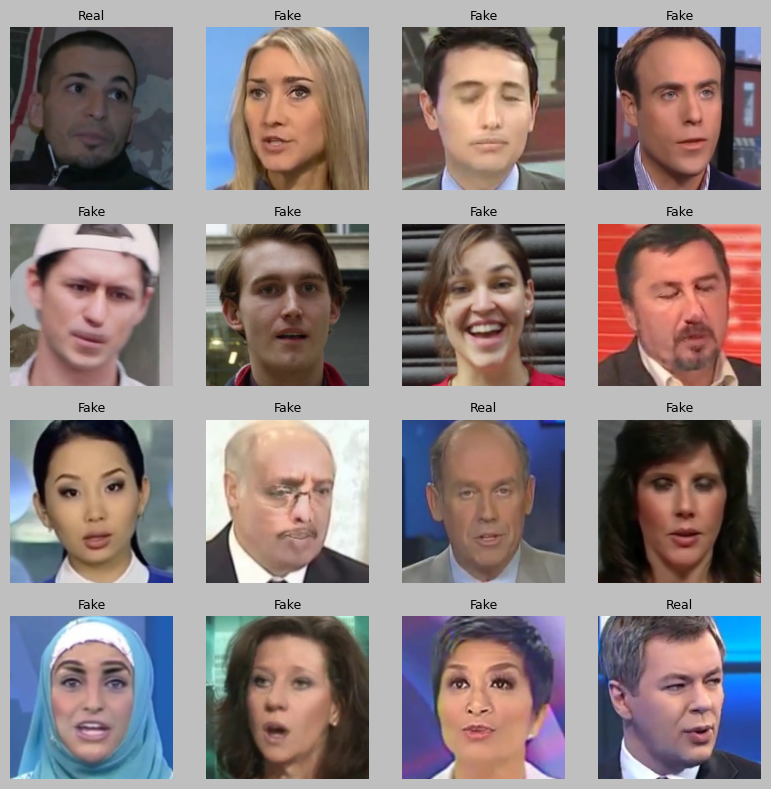

In [6]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
import random

# Yeni klasör yapısına göre kök dizin
DATASET_PATH = "dataset/dataset_processed_split"
train_path = os.path.join(DATASET_PATH, 'train')
test_path = os.path.join(DATASET_PATH, 'test')

print("🔍 1. KLASÖR VE BOZUK DOSYA KONTROLÜ (Hızlı Tarama)")
def get_all_images(directory):
    return glob.glob(os.path.join(directory, '**', '*.*'), recursive=True)

train_imgs = get_all_images(train_path)
test_imgs = get_all_images(test_path)

print(f"Eğitim (Train) Seti Toplam: {len(train_imgs)} kare")
print(f"Test Seti Toplam: {len(test_imgs)} kare")

print("\n🚨 2. DATA LEAKAGE (VERİ SIZINTISI) KONTROLÜ")
# Dosya adlarındaki Video ID'sini çıkarma (örn: 206_221_f346.jpg -> 206_221)
def get_video_ids(image_paths):
    ids = set()
    for path in image_paths:
        filename = os.path.basename(path)
        # '_f' (frame) ibaresinden önceki kısmı Video ID olarak alıyoruz
        if '_f' in filename:
            video_id = filename.split('_f')[0]
            ids.add(video_id)
    return ids

train_video_ids = get_video_ids(train_imgs)
test_video_ids = get_video_ids(test_imgs)

# Kesişim (Intersection) var mı?
leakage = train_video_ids.intersection(test_video_ids)
if len(leakage) > 0:
    print(f"⚠️ DİKKAT! Veri sızıntısı riski tespit edildi. {len(leakage)} video hem Train hem Test setinde var!")
else:
    print("✅ HARİKA! Train ve Test setlerindeki video kaynakları tamamen farklı. Veri Sızıntısı YOK.")

print("\n🖼️ 3. CROP KALİTESİ KONTROLÜ (16 Rastgele Kare)")
sample_imgs = random.sample(train_imgs, min(16, len(train_imgs)))

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    # Klasör adına bakarak etiketleme yapıyoruz
    label = "Real" if "Real" in img_path else "Fake"
    ax.set_title(label, fontsize=9)

plt.tight_layout()
plt.show()

📐 1. ÇÖZÜNÜRLÜK (RESOLUTION) ANALİZİ
Gerçek Yüzler Ortalama Çözünürlük: 224x224
Sahte Yüzler Ortalama Çözünürlük: 224x224

🎨 2. SINIF DENGESİ VE RGB HİSTOGRAMI (PDF OLUŞTURULUYOR...)


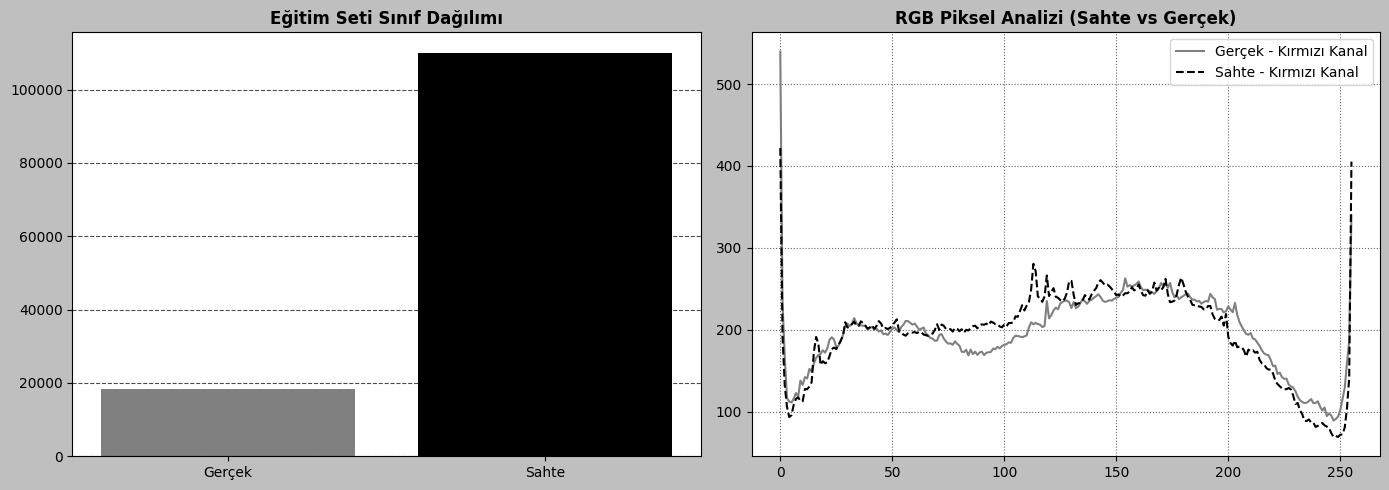

✅ BİTTİ! Sol taraftaki klasör simgesine tıklayıp '03_EDA_Detayli_Analiz.pdf' dosyasını indirebilirsin.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

plt.style.use('grayscale')

DATASET_PATH = "dataset/dataset_processed_split"
train_path = os.path.join(DATASET_PATH, 'train')

# Real ve Fake yollarını ayırma (Fake için 6 klasörü birleştiriyoruz)
real_paths = glob.glob(os.path.join(train_path, 'Real', '*.*'))
fake_paths = []
fake_categories = ['Face2Face', 'DeepFakeDetection', 'FaceSwap', 'Deepfakes', 'FaceShifter', 'NeuralTextures']
for cat in fake_categories:
    fake_paths.extend(glob.glob(os.path.join(train_path, cat, '*.*')))

print("📐 1. ÇÖZÜNÜRLÜK (RESOLUTION) ANALİZİ")
def get_avg_resolution(paths, sample=200):
    samples = paths[:sample] if len(paths) > sample else paths
    widths, heights = [], []
    for p in samples:
        w, h = Image.open(p).size
        widths.append(w)
        heights.append(h)
    return int(np.mean(widths)), int(np.mean(heights))

real_w, real_h = get_avg_resolution(real_paths)
fake_w, fake_h = get_avg_resolution(fake_paths)
print(f"Gerçek Yüzler Ortalama Çözünürlük: {real_w}x{real_h}")
print(f"Sahte Yüzler Ortalama Çözünürlük: {fake_w}x{fake_h}")

print("\n🎨 2. SINIF DENGESİ VE RGB HİSTOGRAMI (PDF OLUŞTURULUYOR...)")
def calc_rgb_hist(paths, sample=200):
    samples = paths[:sample] if len(paths) > sample else paths
    r_hist = np.zeros(256)
    for p in samples:
        img = np.array(Image.open(p).convert('RGB'))
        r_hist += np.histogram(img[:,:,0], bins=256, range=(0,256))[0]
    return r_hist/len(samples)

r_real = calc_rgb_hist(real_paths)
r_fake = calc_rgb_hist(fake_paths)

# 3. 600 DPI PDF GRAFİĞİ OLUŞTURMA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sınıf Dengesi
ax1.bar(['Gerçek', 'Sahte'], [len(real_paths), len(fake_paths)], color=['gray', 'black'])
ax1.set_title('Eğitim Seti Sınıf Dağılımı', fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# RGB Kırmızı Kanal Farklılığı
ax2.plot(r_real, label='Gerçek - Kırmızı Kanal', color='gray', linestyle='-')
ax2.plot(r_fake, label='Sahte - Kırmızı Kanal', color='black', linestyle='--')
ax2.set_title('RGB Piksel Analizi (Sahte vs Gerçek)', fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('03_EDA_Detayli_Analiz.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

print("✅ BİTTİ! Sol taraftaki klasör simgesine tıklayıp '03_EDA_Detayli_Analiz.pdf' dosyasını indirebilirsin.")

In [ ]:
# ==============================================================================
# 04_EXP001_BASELINE: RESNET-18 (AUGMENTATION YOK)
# ==============================================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

plt.style.use('grayscale')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan Donanım: {device}")

# 1. VERİ YÜKLEME VE İKİLİ (BINARY) SINIFLANDIRMA DÖNÜŞÜMÜ
# Baseline olduğu için Data Augmentation (Döndürme vb.) YASAK.
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATASET_PATH = "dataset/dataset_processed_split"
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), transform=baseline_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), transform=baseline_transforms)

# PÜF NOKTASI: Klasörde 7 kategori var. Biz bunu Real(0) ve Fake(1) olarak birleştiriyoruz.
real_class_idx = train_dataset.class_to_idx['Real']
print(f"ℹ️ 'Real' klasörünün orijinal ID'si: {real_class_idx}. Bu ID'yi 0, diğer 6 Fake algoritmasını 1 yapacağız.")

# Hızlı eğitim için DataLoader (Colab T4 GPU için batch=64 uygundur)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. MODEL KURULUMU (ResNet18)
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2) # Çıkış: 0(Real), 1(Fake)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. EĞİTİM DÖNGÜSÜ (TRAINING LOOP)
epochs = 3 # İlk test için 3 epoch yeterli
train_losses, test_losses, test_accuracies = [], [], []

print("\n🚀 EXP001: Model Eğitimi Başlıyor...")
start_time = time.time()

for epoch in range(epochs):
    # EĞİTİM
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        # Etiketleri İkili (Binary) formata çeviriyoruz: Real -> 0, Fake -> 1
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # DOĞRULAMA (TEST)
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(100 * correct / total)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | Test Acc: %{test_accuracies[-1]:.2f}")

training_time = (time.time() - start_time) / 60
print(f"⏱️ Toplam Eğitim Süresi: {training_time:.2f} dakika.")

# 4. DEĞERLENDİRME VE İLERİ DÜZEY METRİKLER (EVALUATION)
print("\n🧪 İleri Düzey Metrikler (Inference & ROC) Hesaplanıyor...")
model.eval()
all_labels, all_preds, all_probs = [], [], []
inference_start = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1] # Sahte (1) olma olasılığı
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time = (time.time() - inference_start) / len(test_dataset)

# Metrik Hesaplamaları
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# 5. CSV LOG KAYDI (Otomatik Raporlama)
log_file = 'experiment_log.csv'
log_data = pd.DataFrame([{
    'EXP_ID': 'EXP001', 'Dataset': 'FF++ C23 Cropped', 'Model': 'ResNet18',
    'Augmentation': 'None', 'Optimizer': 'Adam', 'LR': 0.001, 'Batch': 64, 'Epochs': epochs,
    'Train_Time_min': round(training_time, 2), 'Inference_sec_per_img': round(inference_time, 5),
    'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4),
    'Specificity': round(specificity, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4)
}])

if not os.path.exists(log_file):
    log_data.to_csv(log_file, index=False)
else:
    log_data.to_csv(log_file, mode='a', header=False, index=False)
print(f"📝 Sonuçlar başarıyla '{log_file}' dosyasına kaydedildi!")

# 6. AKADEMİK GRAFİKLER (600 DPI PDF)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# A) Accuracy - Loss Eğrisi
ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', color='black', linestyle='-')
ax1.plot(range(1, epochs+1), test_losses, label='Test Loss', color='gray', linestyle='--')
ax1.set_title('EXP001: Eğitim/Test Kayıp Eğrisi', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle=':')

# B) Confusion Matrix
plt_sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=ax2,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax2.set_title('EXP001: Karmaşıklık Matrisi', fontweight='bold')
ax2.set_ylabel('Gerçek Sınıf')
ax2.set_xlabel('Model Tahmini')

# C) ROC Eğrisi
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax3.plot(fpr, tpr, color='black', label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('EXP001: ROC Eğrisi', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend()
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.savefig('04_EXP001_Sonuclar.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

print("🎉 EXP001 BAŞARIYLA TAMAMLANDI! (04_EXP001_Sonuclar.pdf oluşturuldu)")
print(log_data[['Accuracy', 'F1_Score', 'ROC_AUC', 'Inference_sec_per_img']])

✅ Kullanılan Donanım: cpu
ℹ️ 'Real' klasörünün orijinal ID'si: 6. Bu ID'yi 0, diğer 6 Fake algoritmasını 1 yapacağız.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.9MB/s]



🚀 EXP001: Model Eğitimi Başlıyor...


✅ Kullanılan Donanım: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🚀 EXP002: Veri Artırımlı (Augmentation) Model Eğitimi Başlıyor...
Epoch 1/3 | Train Loss: 0.3366 | Test Loss: 0.3556 | Test Acc: %85.68
Epoch 2/3 | Train Loss: 0.2620 | Test Loss: 0.3310 | Test Acc: %84.74
Epoch 3/3 | Train Loss: 0.2119 | Test Loss: 0.3243 | Test Acc: %88.99

🧪 İleri Düzey Metrikler Hesaplanıyor...
📝 Sonuçlar 'experiment_log.csv' dosyasına başarıyla EKLENDİ!


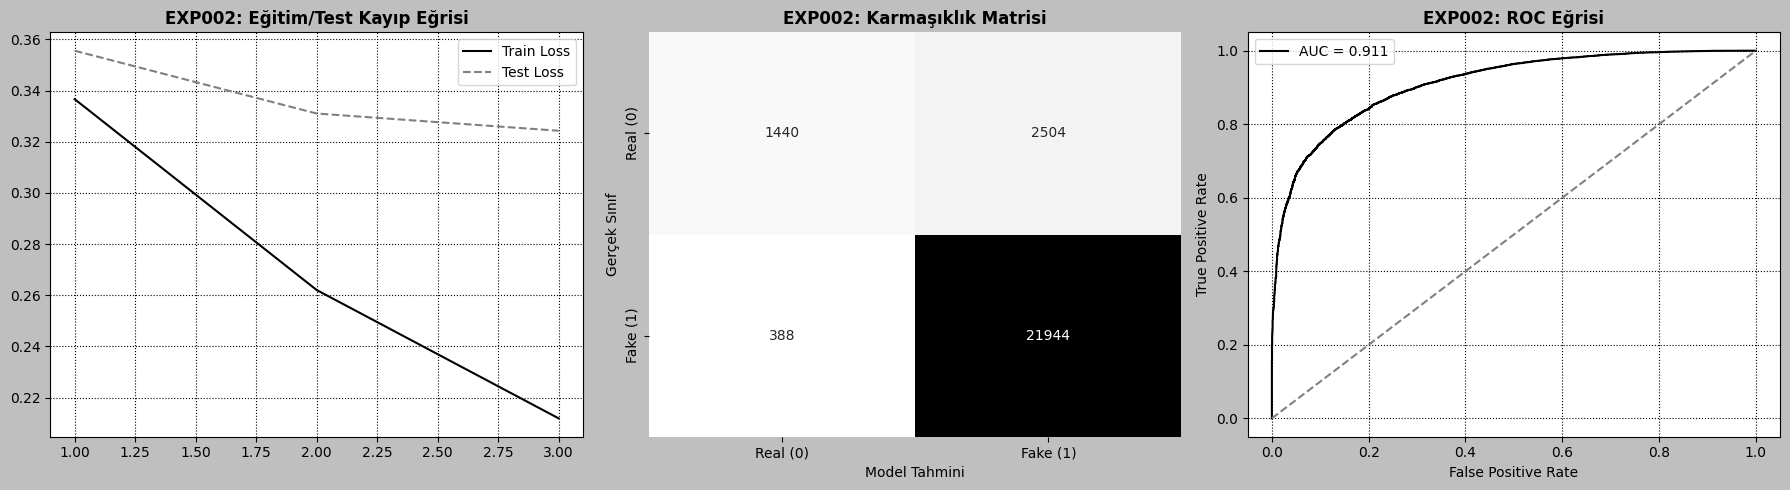

🎉 EXP002 BAŞARIYLA TAMAMLANDI! (05_EXP002_Sonuclar.pdf oluşturuldu)
   Accuracy  F1_Score  ROC_AUC  Specificity
0    0.8899    0.9382   0.9109       0.3651


In [ ]:
# ==============================================================================
# 05_EXP002_AUGMENTATION: RESNET-18 (DATA AUGMENTATION EKLENDİ)
# ==============================================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

plt.style.use('grayscale')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan Donanım: {device}")

# 1. VERİ YÜKLEME VE İKİLİ (BINARY) DÖNÜŞÜM
# ---> DEĞİŞİKLİK BURADA: Eğitim setine Veri Artırımı (Augmentation) uygulandı!
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Rastgele aynalama
    transforms.RandomRotation(degrees=15),  # Sağa sola eğme
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Işık ve kontrast
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# DİKKAT: Test setine ASLA augmentation uygulanmaz! Sadece Resize ve Normalize.
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATASET_PATH = "dataset/dataset_processed_split"
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), transform=test_transforms)

real_class_idx = train_dataset.class_to_idx['Real']
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. MODEL KURULUMU
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. EĞİTİM DÖNGÜSÜ
epochs = 3
train_losses, test_losses, test_accuracies = [], [], []

print("\n🚀 EXP002: Veri Artırımlı (Augmentation) Model Eğitimi Başlıyor...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(100 * correct / total)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | Test Acc: %{test_accuracies[-1]:.2f}")

training_time = (time.time() - start_time) / 60

# 4. DEĞERLENDİRME
print("\n🧪 İleri Düzey Metrikler Hesaplanıyor...")
model.eval()
all_labels, all_preds, all_probs = [], [], []
inference_start = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time = (time.time() - inference_start) / len(test_dataset)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# 5. CSV LOG KAYDI (Otomatik Güncelleme)
log_file = 'experiment_log.csv'
log_data = pd.DataFrame([{
    'EXP_ID': 'EXP002', 'Dataset': 'FF++ C23 Cropped', 'Model': 'ResNet18',
    'Augmentation': 'Flip+Rotate+Jitter', 'Optimizer': 'Adam', 'LR': 0.001, 'Batch': 64, 'Epochs': epochs,
    'Train_Time_min': round(training_time, 2), 'Inference_sec_per_img': round(inference_time, 5),
    'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4),
    'Specificity': round(specificity, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4)
}])

log_data.to_csv(log_file, mode='a', header=False, index=False)
print(f"📝 Sonuçlar '{log_file}' dosyasına başarıyla EKLENDİ!")

# 6. GRAFİKLER
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', color='black', linestyle='-')
ax1.plot(range(1, epochs+1), test_losses, label='Test Loss', color='gray', linestyle='--')
ax1.set_title('EXP002: Eğitim/Test Kayıp Eğrisi', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle=':')

plt_sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=ax2,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax2.set_title('EXP002: Karmaşıklık Matrisi', fontweight='bold')
ax2.set_ylabel('Gerçek Sınıf')
ax2.set_xlabel('Model Tahmini')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax3.plot(fpr, tpr, color='black', label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('EXP002: ROC Eğrisi', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend()
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.savefig('05_EXP002_Sonuclar.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

print("🎉 EXP002 BAŞARIYLA TAMAMLANDI! (05_EXP002_Sonuclar.pdf oluşturuldu)")
print(log_data[['Accuracy', 'F1_Score', 'ROC_AUC', 'Specificity']])

✅ Kullanılan Donanım: cuda

🚀 EXP003: Düşük Learning Rate (0.0001) ile Model Eğitimi Başlıyor...
Epoch 1/3 | Train Loss: 0.1220 | Test Loss: 0.2157 | Test Acc: %92.23
Epoch 2/3 | Train Loss: 0.0428 | Test Loss: 0.3086 | Test Acc: %92.50
Epoch 3/3 | Train Loss: 0.0286 | Test Loss: 0.1827 | Test Acc: %94.12

🧪 İleri Düzey Metrikler Hesaplanıyor...
📝 Sonuçlar 'experiment_log.csv' dosyasına başarıyla EKLENDİ!


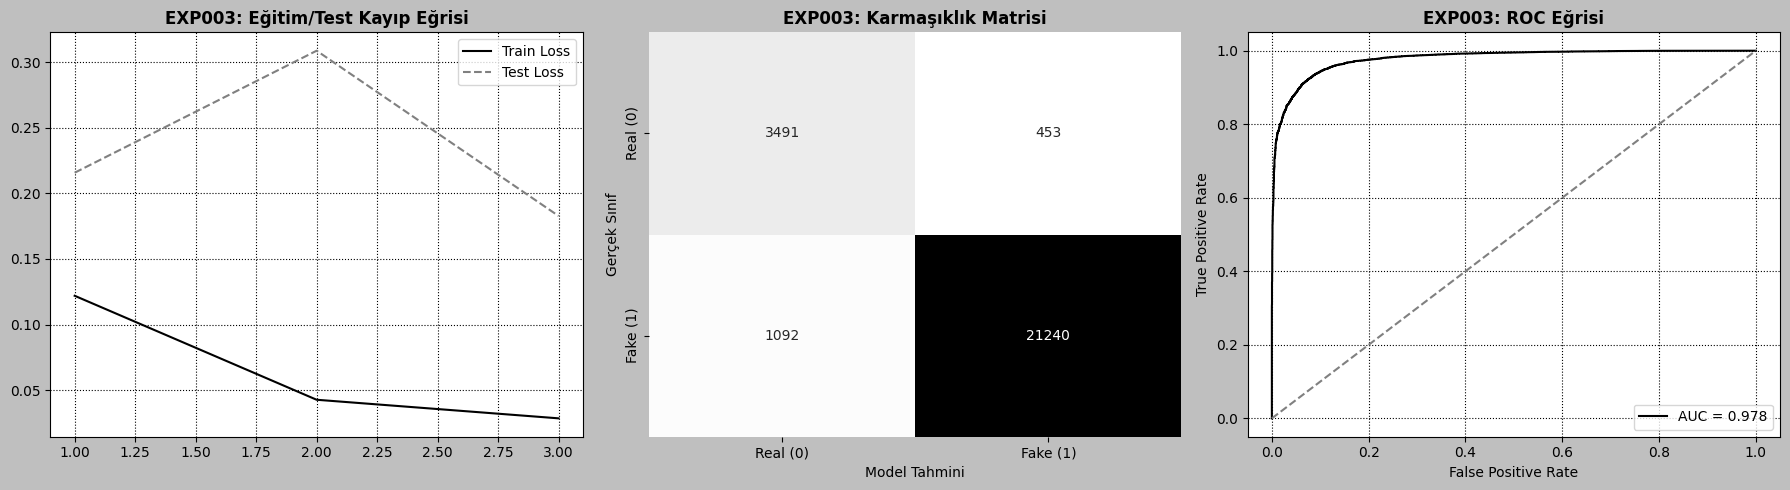

🎉 EXP003 BAŞARIYLA TAMAMLANDI! (06_EXP003_Sonuclar.pdf oluşturuldu)
   Accuracy  F1_Score  ROC_AUC  Specificity
0    0.9412    0.9649   0.9782       0.8851


In [ ]:
# ==============================================================================
# 06_EXP003_LEARNING_RATE: RESNET-18 (LR: 0.0001)
# ==============================================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

plt.style.use('grayscale')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan Donanım: {device}")

# 1. VERİ YÜKLEME (Augmentation yok, sadece Baseline)
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATASET_PATH = "dataset/dataset_processed_split"
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), transform=baseline_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), transform=baseline_transforms)

real_class_idx = train_dataset.class_to_idx['Real']
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. MODEL KURULUMU
# ---> DEĞİŞİKLİK 1: Modern ağırlık yükleme yöntemi kullanıldı
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# ---> DEĞİŞİKLİK 2: Learning Rate (Öğrenme Oranı) 0.001'den 0.0001'e düşürüldü
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 3. EĞİTİM DÖNGÜSÜ
epochs = 3
train_losses, test_losses, test_accuracies = [], [], []

print("\n🚀 EXP003: Düşük Learning Rate (0.0001) ile Model Eğitimi Başlıyor...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(100 * correct / total)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | Test Acc: %{test_accuracies[-1]:.2f}")

training_time = (time.time() - start_time) / 60

# 4. DEĞERLENDİRME
print("\n🧪 İleri Düzey Metrikler Hesaplanıyor...")
model.eval()
all_labels, all_preds, all_probs = [], [], []
inference_start = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time = (time.time() - inference_start) / len(test_dataset)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# 5. CSV LOG KAYDI
log_file = 'experiment_log.csv'
log_data = pd.DataFrame([{
    'EXP_ID': 'EXP003', 'Dataset': 'FF++ C23 Cropped', 'Model': 'ResNet18',
    'Augmentation': 'None', 'Optimizer': 'Adam', 'LR': 0.0001, 'Batch': 64, 'Epochs': epochs,
    'Train_Time_min': round(training_time, 2), 'Inference_sec_per_img': round(inference_time, 5),
    'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4),
    'Specificity': round(specificity, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4)
}])

log_data.to_csv(log_file, mode='a', header=False, index=False)
print(f"📝 Sonuçlar '{log_file}' dosyasına başarıyla EKLENDİ!")

# 6. GRAFİKLER
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', color='black', linestyle='-')
ax1.plot(range(1, epochs+1), test_losses, label='Test Loss', color='gray', linestyle='--')
ax1.set_title('EXP003: Eğitim/Test Kayıp Eğrisi', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle=':')

plt_sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=ax2,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax2.set_title('EXP003: Karmaşıklık Matrisi', fontweight='bold')
ax2.set_ylabel('Gerçek Sınıf')
ax2.set_xlabel('Model Tahmini')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax3.plot(fpr, tpr, color='black', label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('EXP003: ROC Eğrisi', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend()
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.savefig('06_EXP003_Sonuclar.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

print("🎉 EXP003 BAŞARIYLA TAMAMLANDI! (06_EXP003_Sonuclar.pdf oluşturuldu)")
print(log_data[['Accuracy', 'F1_Score', 'ROC_AUC', 'Specificity']])

✅ Kullanılan Donanım: cuda

🚀 EXP004: AdamW Optimizer ile Model Eğitimi Başlıyor...
Epoch 1/3 | Train Loss: 0.2643 | Test Loss: 0.2726 | Test Acc: %89.40
Epoch 2/3 | Train Loss: 0.1464 | Test Loss: 0.2330 | Test Acc: %91.43
Epoch 3/3 | Train Loss: 0.1030 | Test Loss: 0.3083 | Test Acc: %91.65

🧪 İleri Düzey Metrikler Hesaplanıyor...
📝 Sonuçlar 'experiment_log.csv' dosyasına başarıyla EKLENDİ!


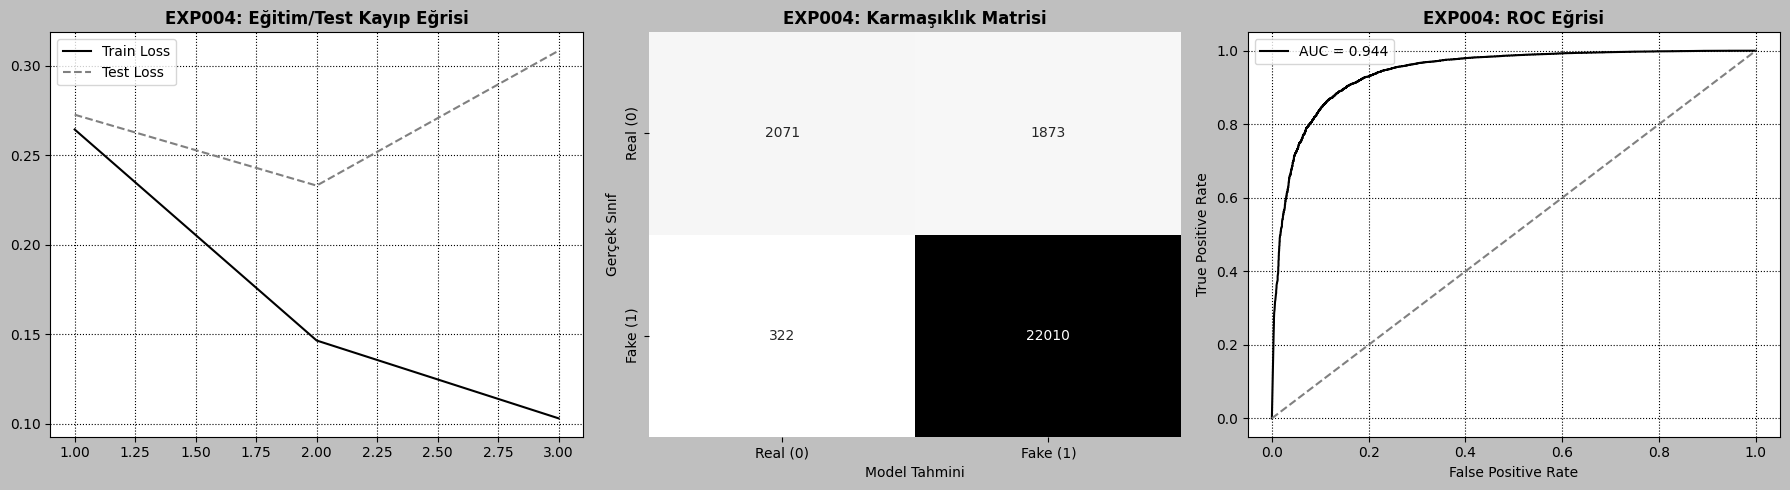

🎉 EXP004 BAŞARIYLA TAMAMLANDI! (07_EXP004_Sonuclar.pdf oluşturuldu)
   Accuracy  F1_Score  ROC_AUC  Specificity
0    0.9165    0.9525   0.9438       0.5251


In [ ]:
# ==============================================================================
# 07_EXP004_OPTIMIZER: RESNET-18 (SADECE ADAMW)
# ==============================================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

plt.style.use('grayscale')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan Donanım: {device}")

# 1. VERİ YÜKLEME (Optimum Reçete: Augmentation Yok)
baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATASET_PATH = "dataset/dataset_processed_split"
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), transform=baseline_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), transform=baseline_transforms)

real_class_idx = train_dataset.class_to_idx['Real']
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. MODEL KURULUMU
# PyTorch uyarısını çözen modern syntax:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# ---> DEĞİŞİKLİK BURADA: Adam yerine AdamW kullanıyoruz (Baseline LR=0.001 korunarak!)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. EĞİTİM DÖNGÜSÜ
epochs = 3
train_losses, test_losses, test_accuracies = [], [], []

print("\n🚀 EXP004: AdamW Optimizer ile Model Eğitimi Başlıyor...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(100 * correct / total)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | Test Acc: %{test_accuracies[-1]:.2f}")

training_time = (time.time() - start_time) / 60

# 4. DEĞERLENDİRME
print("\n🧪 İleri Düzey Metrikler Hesaplanıyor...")
model.eval()
all_labels, all_preds, all_probs = [], [], []
inference_start = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time = (time.time() - inference_start) / len(test_dataset)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# 5. CSV LOG KAYDI
log_file = 'experiment_log.csv'
log_data = pd.DataFrame([{
    'EXP_ID': 'EXP004', 'Dataset': 'FF++ C23 Cropped', 'Model': 'ResNet18',
    'Augmentation': 'None', 'Optimizer': 'AdamW', 'LR': 0.001, 'Batch': 64, 'Epochs': epochs,
    'Train_Time_min': round(training_time, 2), 'Inference_sec_per_img': round(inference_time, 5),
    'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4),
    'Specificity': round(specificity, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4)
}])

log_data.to_csv(log_file, mode='a', header=False, index=False)
print(f"📝 Sonuçlar '{log_file}' dosyasına başarıyla EKLENDİ!")

# 6. GRAFİKLER
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', color='black', linestyle='-')
ax1.plot(range(1, epochs+1), test_losses, label='Test Loss', color='gray', linestyle='--')
ax1.set_title('EXP004: Eğitim/Test Kayıp Eğrisi', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle=':')

plt_sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=ax2,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax2.set_title('EXP004: Karmaşıklık Matrisi', fontweight='bold')
ax2.set_ylabel('Gerçek Sınıf')
ax2.set_xlabel('Model Tahmini')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax3.plot(fpr, tpr, color='black', label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('EXP004: ROC Eğrisi', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend()
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.savefig('07_EXP004_Sonuclar.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

print("🎉 EXP004 BAŞARIYLA TAMAMLANDI! (07_EXP004_Sonuclar.pdf oluşturuldu)")
print(log_data[['Accuracy', 'F1_Score', 'ROC_AUC', 'Specificity']])

✅ Kullanılan Donanım: cuda
🏗️ Modern Mimari Yükleniyor: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 62.0MB/s]



🚀 EXP005: EfficientNet-B0 ile Final Eğitimi Başlıyor...
Epoch 1/3 | Train Loss: 0.1387 | Test Loss: 0.1545 | Test Acc: %94.52
Epoch 2/3 | Train Loss: 0.0507 | Test Loss: 0.1575 | Test Acc: %95.32
Epoch 3/3 | Train Loss: 0.0319 | Test Loss: 0.1935 | Test Acc: %94.42

🧪 Final İleri Düzey Metrikleri Hesaplanıyor...
📝 Final Sonuçları 'experiment_log.csv' dosyasına başarıyla EKLENDİ!


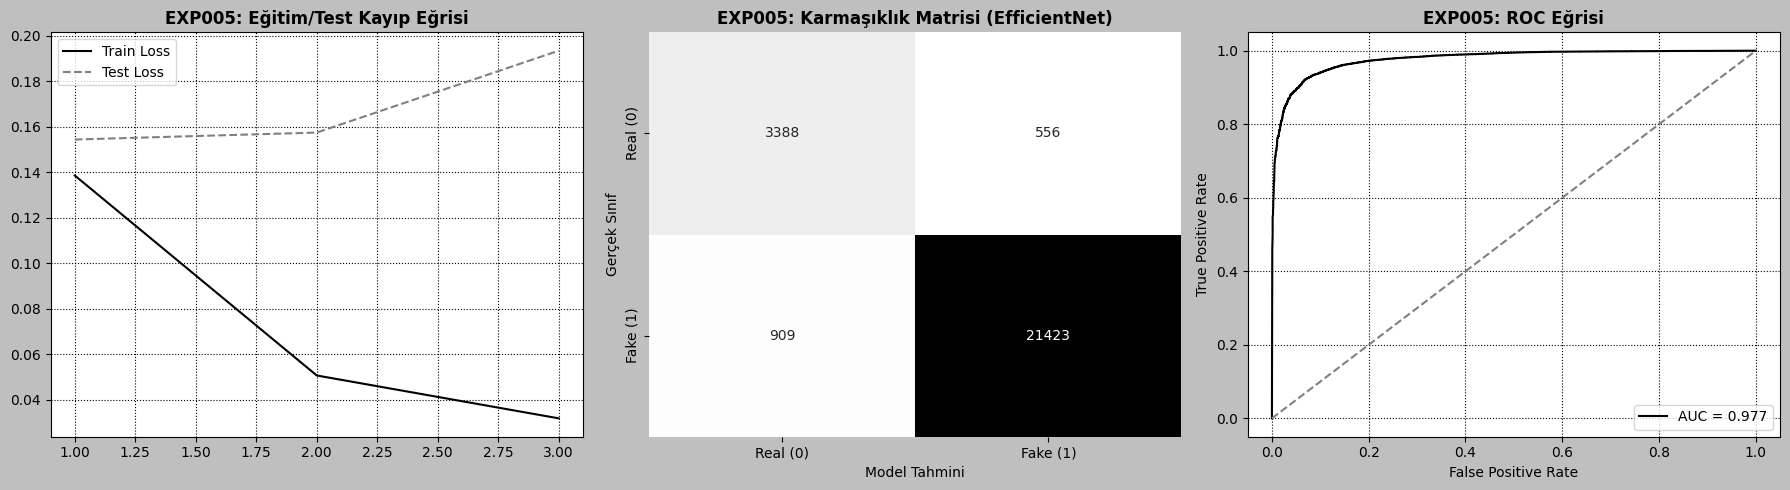

🎉 EXP005 (FİNAL) BAŞARIYLA TAMAMLANDI! (08_EXP005_Sonuclar.pdf oluşturuldu)
   Accuracy  F1_Score  ROC_AUC  Specificity  Train_Time_min
0    0.9442    0.9669    0.977        0.859           35.84


In [ ]:
# ==============================================================================
# 08_EXP005_EFFICIENTNET: MODERN MİMARİ KARŞILAŞTIRMASI (EfficientNet-B0)
# ==============================================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

plt.style.use('grayscale')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Kullanılan Donanım: {device}")

# 1. VERİ YÜKLEME (Optimum Reçete: Augmentation Yok)
optimum_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DATASET_PATH = "dataset/dataset_processed_split"
train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'train'), transform=optimum_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, 'test'), transform=optimum_transforms)

real_class_idx = train_dataset.class_to_idx['Real']
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. MODEL KURULUMU (RESNET18 ÇÖPE, EFFICIENTNET-B0 SAHNEYE)
print("🏗️ Modern Mimari Yükleniyor: EfficientNet-B0")
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# EfficientNet'te son katman 'fc' değil 'classifier' olarak geçer
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Optimum Reçete: Düşük LR (0.0001) ve Standart Adam
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 3. EĞİTİM DÖNGÜSÜ
epochs = 3
train_losses, test_losses, test_accuracies = [], [], []

print("\n🚀 EXP005: EfficientNet-B0 ile Final Eğitimi Başlıyor...")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(100 * correct / total)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} | Test Acc: %{test_accuracies[-1]:.2f}")

training_time = (time.time() - start_time) / 60

# 4. DEĞERLENDİRME
print("\n🧪 Final İleri Düzey Metrikleri Hesaplanıyor...")
model.eval()
all_labels, all_preds, all_probs = [], [], []
inference_start = time.time()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = torch.where(labels == real_class_idx, torch.tensor(0), torch.tensor(1)).to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time = (time.time() - inference_start) / len(test_dataset)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# 5. CSV LOG KAYDI
log_file = 'experiment_log.csv'
log_data = pd.DataFrame([{
    'EXP_ID': 'EXP005', 'Dataset': 'FF++ C23 Cropped', 'Model': 'EfficientNet-B0',
    'Augmentation': 'None', 'Optimizer': 'Adam', 'LR': 0.0001, 'Batch': 64, 'Epochs': epochs,
    'Train_Time_min': round(training_time, 2), 'Inference_sec_per_img': round(inference_time, 5),
    'Accuracy': round(acc, 4), 'Precision': round(prec, 4), 'Recall': round(rec, 4),
    'Specificity': round(specificity, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4)
}])

log_data.to_csv(log_file, mode='a', header=False, index=False)
print(f"📝 Final Sonuçları '{log_file}' dosyasına başarıyla EKLENDİ!")

# 6. GRAFİKLER
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', color='black', linestyle='-')
ax1.plot(range(1, epochs+1), test_losses, label='Test Loss', color='gray', linestyle='--')
ax1.set_title('EXP005: Eğitim/Test Kayıp Eğrisi', fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle=':')

plt_sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=ax2,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax2.set_title('EXP005: Karmaşıklık Matrisi (EfficientNet)', fontweight='bold')
ax2.set_ylabel('Gerçek Sınıf')
ax2.set_xlabel('Model Tahmini')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax3.plot(fpr, tpr, color='black', label=f'AUC = {auc:.3f}')
ax3.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax3.set_title('EXP005: ROC Eğrisi', fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend()
ax3.grid(True, linestyle=':')

plt.tight_layout()
plt.savefig('08_EXP005_Sonuclar.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

print("🎉 EXP005 (FİNAL) BAŞARIYLA TAMAMLANDI! (08_EXP005_Sonuclar.pdf oluşturuldu)")
print(log_data[['Accuracy', 'F1_Score', 'ROC_AUC', 'Specificity', 'Train_Time_min']])